In [ ]:
import torch
from torch import nn
from d2l import torch as d2l


# X:	    앞 Layer가 출력한 activation
# gamma:	Learnable scale
# beta :	Learnable shift
# moving_mean:	Prediction용 mean
# moving_var :	Prediction용 variance
# eps:	Division by zero 방지
# momentum	현재 statistics 반영 비율
# Y	Batch Normalization 결과

In [14]:
# Batch Normalization Function

def batch_norm(
    X: torch.Tensor,
    gamma: torch.Tensor,
    beta: torch.Tensor,
    moving_mean: torch.Tensor,
    moving_var: torch.Tensor,
    eps: float,
    momentum: float,
) -> tuple[
    torch.Tensor,
    torch.Tensor,
    torch.Tensor,
]:
    # Prediction에서는 누적된 statistics 사용
    if not torch.is_grad_enabled():
        X_hat = (
            X - moving_mean
        ) / torch.sqrt(
            moving_var + eps
        )

    # Training에서는 현재 minibatch statistics 사용
    else:
        if X.ndim not in (2, 4):
            raise ValueError(
                "X must be a 2D or 4D tensor."
            )

        # Fully Connected: feature별 normalization
        # [B, F] -> mean과 variance: [F]
        if X.ndim == 2:
            mean = X.mean(
                dim=0,
            )

            var = (
                (X - mean) ** 2
            ).mean(
                dim=0,
            )

        # Convolution: channel별 normalization
        # [B, C, H, W] -> mean과 variance: [1, C, 1, 1]
        else:
            mean = X.mean(
                dim=(0, 2, 3),
                keepdim=True,
            )

            var = (
                (X - mean) ** 2
            ).mean(
                dim=(0, 2, 3),
                keepdim=True,
            )

        X_hat = (
            X - mean
        ) / torch.sqrt(
            var + eps
        )

        # Prediction에서 사용할 moving statistics update
        moving_mean = (
            (1.0 - momentum) * moving_mean
            + momentum * mean
        )

        moving_var = (
            (1.0 - momentum) * moving_var
            + momentum * var
        )

    # Learnable scale과 shift 적용
    Y = gamma * X_hat + beta

    return (
        Y,
        moving_mean.detach(),
        moving_var.detach(),
    )

In [15]:
# Custom BatchNorm Layer

class BatchNorm(nn.Module):
    def __init__(
        self,
        num_features: int,
        num_dims: int,
    ) -> None:
        super().__init__()

        # Fully Connected Parameter shape
        if num_dims == 2:
            shape = (
                1,
                num_features,
            )

        # Convolution Parameter shape
        elif num_dims == 4:
            shape = (
                1,
                num_features,
                1,
                1,
            )

        else:
            raise ValueError(
                "num_dims must be 2 or 4."
            )

        # Learnable scale과 shift
        self.gamma = nn.Parameter(
            torch.ones(
                shape,
            )
        )

        self.beta = nn.Parameter(
            torch.zeros(
                shape,
            )
        )

        # Prediction에서 사용할 moving statistics
        self.moving_mean: torch.Tensor = torch.zeros(
            shape,
        )

        self.moving_var: torch.Tensor = torch.ones(
            shape,
        )

    def forward(
        self,
        X: torch.Tensor,
    ) -> torch.Tensor:
        # Moving statistics를 X와 같은 device로 이동
        if self.moving_mean.device != X.device:
            self.moving_mean = self.moving_mean.to(
                X.device
            )

            self.moving_var = self.moving_var.to(
                X.device
            )

        Y, self.moving_mean, self.moving_var = batch_norm(
            X,
            self.gamma,
            self.beta,
            self.moving_mean,
            self.moving_var,
            eps=1e-5,
            momentum=0.1,
        )

        return Y

In [16]:
# Batch Normalization을 적용한 LeNet

class BNLeNetScratch(d2l.Classifier):
    def __init__(
        self,
        lr: float = 0.1,
        num_classes: int = 10,
    ) -> None:
        
        super().__init__()
        
        self.save_hyperparameters()
        
        self.net = nn.Sequential(
            
            # Convolution Block 1
            # [B, 1, 28, 28] -> [B, 6, 24, 24]
            nn.LazyConv2d(
                out_channels=6,
                kernel_size=5,
            ),
            BatchNorm(
                num_features=6,
                num_dims=4,
            ),
            nn.Sigmoid(),
            
            
            # [B, 6, 24, 24] -> [B, 6, 12, 12]
            nn.AvgPool2d(
                kernel_size=2,
                stride=2,
            ),
            
            
            
            # Convolution Block 2
            # [B, 6, 12, 12] -> [B, 16, 8, 8]
            nn.LazyConv2d(
                out_channels=16,
                kernel_size=5,
            ),
            BatchNorm(
                num_features=16,
                num_dims=4,
            ),
            nn.Sigmoid(),

            # [B, 16, 8, 8] -> [B, 16, 4, 4]
            nn.AvgPool2d(
                kernel_size=2,
                stride=2,
            ),
            
            
            # [B, 16, 4, 4] -> [B, 256]
            nn.Flatten(),


            # Fully Connected Block 1
            # [B, 256] -> [B, 120]
            nn.LazyLinear(
                out_features=120,
            ),
            BatchNorm(
                num_features=120,
                num_dims=2,
            ),
            nn.Sigmoid(),


            # Fully Connected Block 2
            # [B, 120] -> [B, 84]
            nn.LazyLinear(
                out_features=84,
            ),
            BatchNorm(
                num_features=84,
                num_dims=2,
            ),
            nn.Sigmoid(),


            # [B, 84] -> [B, 10] logits
            nn.LazyLinear(
                out_features=num_classes,
            ),
        )

In [17]:
# Tensor Shape & Parameter 수 확인 

model = BNLeNetScratch()

sample_input = torch.randn(
    2,
    1,
    28,
    28,
)

model.apply_init(
    [sample_input],
    d2l.init_cnn,
)

X: torch.Tensor = sample_input

with torch.no_grad():
    for layer in model.net:
        X = layer(X)

        print(
            f"{layer.__class__.__name__:<12}",
            "output shape:",
            tuple(X.shape),
        )

parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print(
    "Parameter count:",
    f"{parameter_count:,}",
)

Conv2d       output shape: (2, 6, 24, 24)
BatchNorm    output shape: (2, 6, 24, 24)
Sigmoid      output shape: (2, 6, 24, 24)
AvgPool2d    output shape: (2, 6, 12, 12)
Conv2d       output shape: (2, 16, 8, 8)
BatchNorm    output shape: (2, 16, 8, 8)
Sigmoid      output shape: (2, 16, 8, 8)
AvgPool2d    output shape: (2, 16, 4, 4)
Flatten      output shape: (2, 256)
Linear       output shape: (2, 120)
BatchNorm    output shape: (2, 120)
Sigmoid      output shape: (2, 120)
Linear       output shape: (2, 84)
BatchNorm    output shape: (2, 84)
Sigmoid      output shape: (2, 84)
Linear       output shape: (2, 10)
Parameter count: 44,878


In [18]:
# Device Checking

num_gpus = (
    1
    if torch.cuda.is_available()
    else 0
)

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

data = d2l.FashionMNIST(
    batch_size=128,
)

model = BNLeNetScratch(
    lr=0.1,
)

trainer = d2l.Trainer(
    max_epochs=10,
    num_gpus=num_gpus,
)

initialization_batch, _ = next(
    iter(
        data.get_dataloader(
            train=True,
        )
    )
)

model.apply_init(
    [initialization_batch],
    d2l.init_cnn,
)

print(
    "Training device:",
    device,
)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0),
    )

print(
    "Training batch shape:",
    tuple(initialization_batch.shape),
)

Training device: cuda
GPU: NVIDIA GeForce RTX 3060 Ti
Training batch shape: (128, 1, 28, 28)


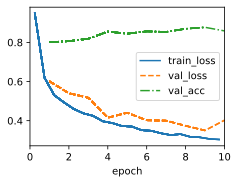

In [19]:
# Fashion-MNIST Training

trainer.fit(
    model,
    data,
)

In [20]:
# 학습된 Gamma와 Beta 확인

# 첫 Conv2d 다음에 있는 BatchNorm
first_batch_norm = model.net[1]

if not isinstance(
    first_batch_norm,
    BatchNorm,
):
    raise TypeError(
        "model.net[1] must be BatchNorm."
    )

print(
    "Gamma:",
    first_batch_norm.gamma.detach().reshape(
        -1
    ).cpu(),
)

print(
    "Beta:",
    first_batch_norm.beta.detach().reshape(
        -1
    ).cpu(),
)

Gamma: tensor([1.3508, 1.4852, 1.8298, 1.6715, 2.4538, 2.1204])
Beta: tensor([-0.4278, -1.0238,  1.2146, -0.9769, -0.5291, -1.3950])
